In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.max_open_warning'] = 0

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import re


In [2]:
# ファイルパス設定
folder_path = r"C:\Users\wb512463\OneDrive - WBG\Resilient Housing\Global analysis\data_processed"
data_file_path = os.path.join(folder_path, "global_analysis_final_for_modeling.csv")
metadata_file_path = os.path.join(folder_path, "column_metadata_final_for_analysis.json")

# データ読み込み
print("データ読み込み中...")
df_analysis = pd.read_csv(data_file_path, encoding='utf-8-sig', low_memory=False)

with open(metadata_file_path, 'r', encoding='utf-8') as f:
    COLUMN_METADATA_LOADED = json.load(f)

print(f"✅ データ読み込み完了: {df_analysis.shape}")
print(f"列数: {len(df_analysis.columns)}")



データ読み込み中...
✅ データ読み込み完了: (217, 101)
列数: 101


# Check Variable List

In [3]:
# 1. データフレームの列名とデータ型を取得
column_info = df_analysis.dtypes.reset_index()
column_info.columns = ['Variable Name', 'Data Type']

# 2. **新しいステップ: 各列の有効な（非欠損の）カウントを取得**
#    DataFrame.count()は非NA値の数を返します
valid_counts = df_analysis.count().reset_index()
valid_counts.columns = ['Variable Name', 'Valid Count']

# 3. メタデータ（説明）をデータフレーム形式に変換
#    (COLUMN_METADATA_LOADEDが辞書であることを前提としています)
metadata_df = pd.DataFrame(COLUMN_METADATA_LOADED.items(), columns=['Variable Name', 'Description'])

# 4. すべてのデータフレームを列名 (Variable Name) をキーとして結合
integrated_list = pd.merge(column_info, valid_counts, on='Variable Name', how='left')
integrated_list = pd.merge(integrated_list, metadata_df, on='Variable Name', how='left')

# 5. 表示用にデータ型を読みやすい形式に変換
integrated_list['Data Type'] = integrated_list['Data Type'].astype(str)

# 説明が見つからない場合の処理
integrated_list['Description'] = integrated_list['Description'].fillna('❌ Description Not Found in JSON')

# 結果の出力
print("\n" + "="*80)
print(f"📊 Integrated Variable List (Total Observations: {len(df_analysis)})")
print("="*80)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    # 'Valid Count'でソートし、欠損が多い順（データが少ない順）に確認できるようにします
    print(integrated_list.sort_values(by='Valid Count', ascending=True).to_string(index=False))

print("="*80)
print("Note: Variables with a lower 'Valid Count' have more missing data.")
print("="*80)



📊 Integrated Variable List (Total Observations: 217)
                          Variable Name Data Type  Valid Count                                                            Description
                                    MPI   float64          109                                Multi-dimenstional Poverty Index - 2025
                  MPI_SCHOOL_ATTENDANCE    object          109                 Percentage of people deprived in school attendance - %
                    MPI_CHILD_MORTALITY    object          109                   Percentage of people deprived in child mortality - %
                          MPI_NUTRITION    object          109                         Percentage of people deprived in nutrition - %
                               MPI_YEAR    object          109 Calendar year of the survey used for the MPI source - Categorical Data
                             MPI_SURVEY    object          109          Name of the survey used for the MPI source - Categorical Data
        

# 1. Check Variables and correlation "in" each dataset 

## disaster data 

📈 ステップ 1-1: Disaster Data (DIS) 相関分析 (実データ分析モード)
✅ ステップ 1完了: オリジナル災害指標の NaN を 0 で補完しました。

📊 補完後の基本統計:
       DIS_TOTAL_DEATHS  DIS_TOTAL_DAMAGE_USD   DIS_TOTAL
count        217.000000          2.170000e+02  217.000000
mean        5264.797235          1.475584e+10   34.400922
std        24992.410604          9.446836e+10   67.221446
min            0.000000          0.000000e+00    0.000000
25%            8.000000          2.000000e+06    4.000000
50%           72.000000          2.708390e+08   15.000000
75%          430.000000          3.447775e+09   40.000000
max       232783.000000          1.233993e+12  553.000000

✅ ステップ 2完了: 正規化指標を計算しました。

📊 正規化指標の基本統計:
       DEATHS_PER_1K_POP  DAMAGE_AS_PCT_GDP  EVENTS_PER_100K_POP
count         217.000000         214.000000           217.000000
mean            0.185837           9.623252             1.055444
std             1.366183          49.242699             2.670569
min             0.000000           0.000000             0.000000
25%      

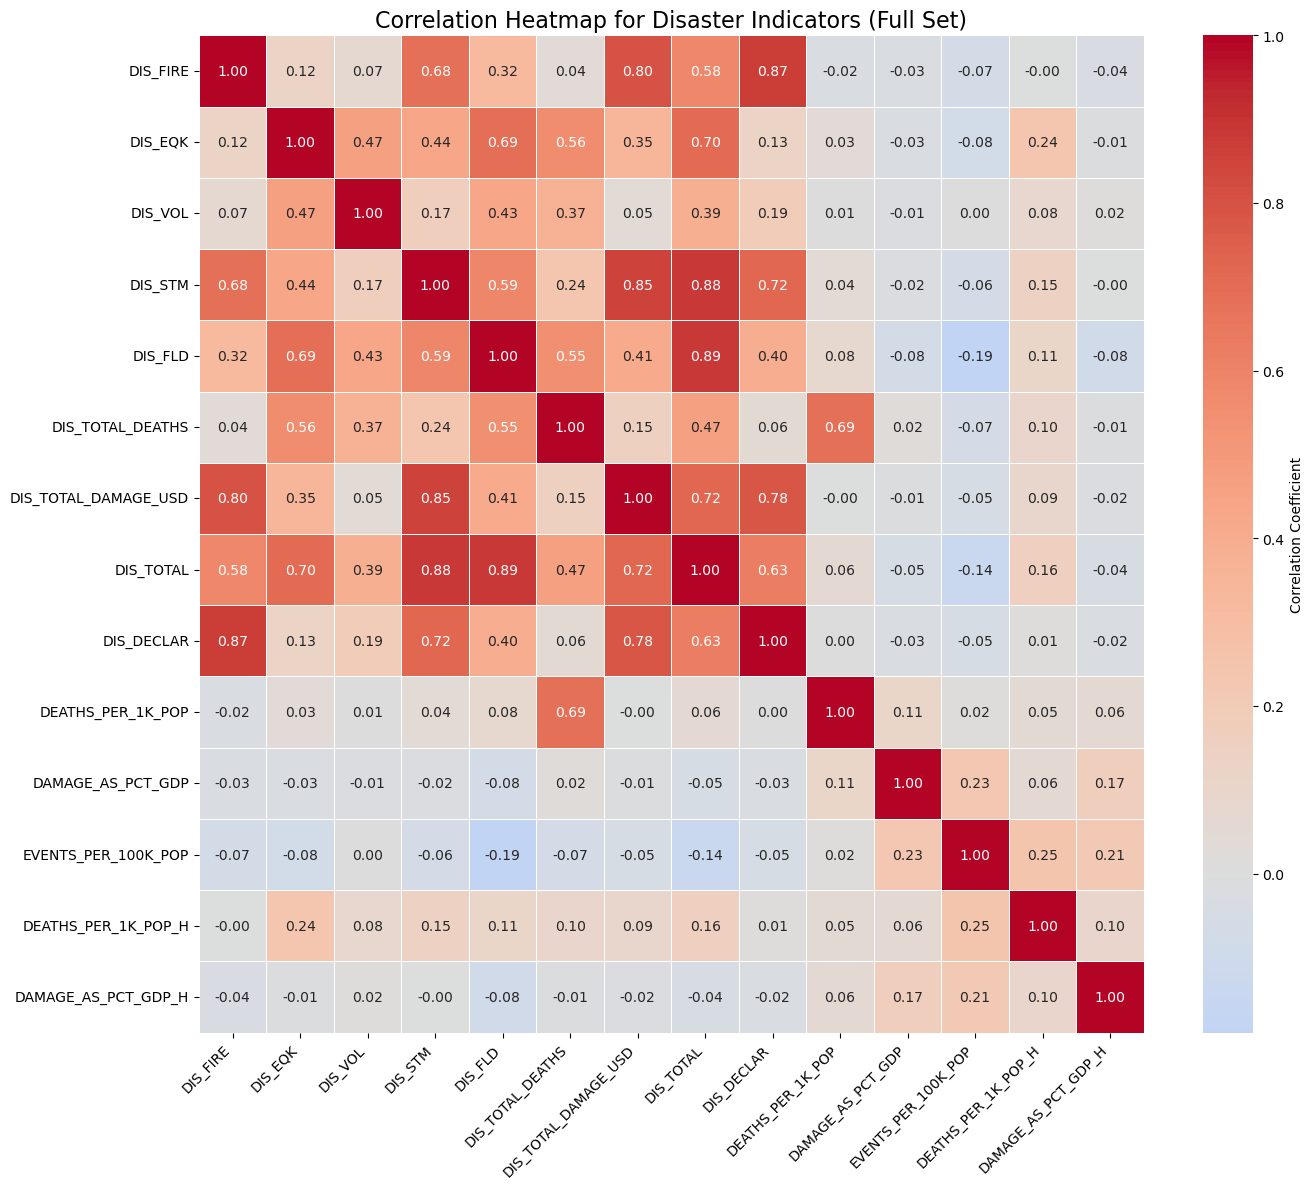


--- 相関行列（Disaster Data & Normalized Metrics） ---
                      DIS_FIRE  DIS_EQK  DIS_VOL  DIS_STM  DIS_FLD  DIS_TOTAL_DEATHS  DIS_TOTAL_DAMAGE_USD  DIS_TOTAL  DIS_DECLAR  DEATHS_PER_1K_POP  DAMAGE_AS_PCT_GDP  EVENTS_PER_100K_POP  DEATHS_PER_1K_POP_H  DAMAGE_AS_PCT_GDP_H
DIS_FIRE                  1.00     0.12     0.07     0.68     0.32              0.04                  0.80       0.58        0.87              -0.02              -0.03                -0.07                -0.00                -0.04
DIS_EQK                   0.12     1.00     0.47     0.44     0.69              0.56                  0.35       0.70        0.13               0.03              -0.03                -0.08                 0.24                -0.01
DIS_VOL                   0.07     0.47     1.00     0.17     0.43              0.37                  0.05       0.39        0.19               0.01              -0.01                 0.00                 0.08                 0.02
DIS_STM                   

In [43]:


# -----------------------------------------------------------
# 1. データフレームの読み込み/存在確認 (実務前提)
# -----------------------------------------------------------
# NOTE: このコードは、外部で事前に 'df_analysis' が定義・読み込み済みであることを前提とします。
# もし df_analysis が存在しない場合は、エラーが発生します。

# df_analysis が存在しない場合は NameError、空の場合は ValueError を発生させます。
if 'df_analysis' not in locals():
    # 実務環境では、ここでCSVやデータベースから df_analysis を読み込みます。
    # 例: df_analysis = pd.read_csv('your_analysis_data.csv')
    raise NameError("エラー: 'df_analysis' が未定義です。分析を開始する前に、必要なデータフレームをロードしてください。")
elif len(df_analysis) == 0:
    raise ValueError("エラー: 'df_analysis' が空です。データが含まれていることを確認してください。")

print("="*60)
print("📈 ステップ 1-1: Disaster Data (DIS) 相関分析 (実データ分析モード)")
print("="*60)

# 作業用コピーを作成
df_temp = df_analysis.copy()

# -----------------------------------------------------------
# ステップ 1: オリジナルDISデータの欠損値を0で補完
# -----------------------------------------------------------
dis_cols_to_fill = [
    'DIS_FIRE', 'DIS_EQK', 'DIS_VOL', 'DIS_STM', 'DIS_FLD',
    'DIS_TOTAL_DEATHS', 'DIS_TOTAL_DAMAGE_USD',
    'DIS_TOTAL', 'DIS_DECLAR'
]
df_temp[dis_cols_to_fill] = df_temp[dis_cols_to_fill].fillna(0)
print("✅ ステップ 1完了: オリジナル災害指標の NaN を 0 で補完しました。")

# 補完後のデータ確認
print(f"\n📊 補完後の基本統計:")
print(df_temp[['DIS_TOTAL_DEATHS', 'DIS_TOTAL_DAMAGE_USD', 'DIS_TOTAL']].describe())

# -----------------------------------------------------------
# ステップ 2: 正規化指標の作成
# -----------------------------------------------------------
# ゼロ除算回避のため、0を微小値に置き換え
POP_K_SAFE = (df_temp['WB_POPULATION_TOTAL_VALUE'] / 1000).replace(0, 1e-6)
GDP_SAFE = df_temp['WB_GDP_USD_CURRENT_VALUE'].replace(0, 1e-6)

# 正規化指標の計算
df_temp['DEATHS_PER_1K_POP'] = df_temp['DIS_TOTAL_DEATHS'] / POP_K_SAFE
df_temp['DAMAGE_AS_PCT_GDP'] = (df_temp['DIS_TOTAL_DAMAGE_USD'] / GDP_SAFE) * 100
df_temp['EVENTS_PER_100K_POP'] = (df_temp['DIS_TOTAL'] / POP_K_SAFE) * 100
df_temp['DEATHS_PER_1K_POP_H'] = df_temp['DIS_TOTAL_DEATHS_HISTORY'] / POP_K_SAFE
df_temp['DAMAGE_AS_PCT_GDP_H'] = (df_temp['DIS_TOTAL_DAMAGE_USD_HISTORY'] / GDP_SAFE) * 100

print("\n✅ ステップ 2完了: 正規化指標を計算しました。")

# 正規化指標の確認
print(f"\n📊 正規化指標の基本統計:")
print(df_temp[['DEATHS_PER_1K_POP', 'DAMAGE_AS_PCT_GDP', 'EVENTS_PER_100K_POP']].describe())

# -----------------------------------------------------------
# ⭐ ステップ 3: 正規化指標を元のdf_analysisに統合 (修正点)
# -----------------------------------------------------------
new_normalized_cols = ['DEATHS_PER_1K_POP', 'DAMAGE_AS_PCT_GDP', 'EVENTS_PER_100K_POP','DEATHS_PER_1K_POP_H','DAMAGE_AS_PCT_GDP_H']

# df_analysisに、df_tempで計算した正規化指標を追加
df_analysis = df_analysis.assign(**df_temp[new_normalized_cols])

print(f"\n⭐ 統合修正完了: {new_normalized_cols} を df_analysis に恒久的に統合しました。")
print(f"df_analysisの列数: {df_analysis.shape[1]}")

# -----------------------------------------------------------
# ステップ 4: 相関分析用データフレーム作成 & inf/NaNの処理
# -----------------------------------------------------------
dis_analysis_cols = dis_cols_to_fill + [
    'DEATHS_PER_1K_POP', 'DAMAGE_AS_PCT_GDP', 'EVENTS_PER_100K_POP','DEATHS_PER_1K_POP_H','DAMAGE_AS_PCT_GDP_H'
]

df_dis_final = df_temp[dis_analysis_cols].copy()

df_dis_final = df_dis_final.replace([np.inf, -np.inf], np.nan)

# 🔍 NaNがある列を確認
print(f"\n🔍 各列のNaN数:")
print(df_dis_final.isna().sum())

# NaNを0で補完（相関計算のため）
df_dis_final = df_dis_final.fillna(0)

# 分散が0の列（全て同じ値の列）をチェック
variance_check = df_dis_final.var()
zero_variance_cols = variance_check[variance_check == 0].index.tolist()
if zero_variance_cols:
    print(f"\n⚠️  警告: 以下の列は分散が0です（全て同じ値）:")
    for col in zero_variance_cols:
        print(f"  - {col}: 値 = {df_dis_final[col].iloc[0]}")

# -----------------------------------------------------------
# ステップ 5: 相関分析
# -----------------------------------------------------------
analysis_sample_size = df_dis_final.shape[0]
print(f"\n✅ 相関分析に使用されたデータ件数 (N): {analysis_sample_size} 件")
print("-" * 60)

# 相関行列の計算
correlation_matrix_dis = df_dis_final.corr()

# ヒートマップ
plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix_dis,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Correlation Coefficient'},
    center=0
)
plt.title('Correlation Heatmap for Disaster Indicators (Full Set)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 相関結果の表示
print("\n--- 相関行列（Disaster Data & Normalized Metrics） ---")
print(correlation_matrix_dis.round(2).to_string())
print("-" * 60)

print("\n--- ハイライト：正規化指標とオリジナル指標の相関 ---")
highlight_cols = ['DEATHS_PER_1K_POP', 'DAMAGE_AS_PCT_GDP', 'EVENTS_PER_100K_POP']
print(correlation_matrix_dis.loc[dis_cols_to_fill, highlight_cols].round(2).to_string())
print("-" * 60)

## Vulnerability Data


⚙️ ステップ 1-2 FINAL FIX: VULN指標の集計と統合 (Water指標の計算堅牢化)
Calculated aggregated indices for: {'EARTHQUAKE', 'FLOOD', 'DEFAULT', 'TSUNAMI', 'WIND', 'STORM_SURGE'}
Dropped 15 old/component VULN columns from df_analysis.
--- 🔧 VULN集計指標のメインデータフレームへの統合 ---
Merged 17 new aggregated VULN indices into df_analysis: ['VULN_DEFAULT_ROBUST_ONLY', 'VULN_DEFAULT_ROBUSTNESS', 'VULN_DEFAULT_VULNERABILITY', 'VULN_EARTHQUAKE_ROBUST_ONLY', 'VULN_EARTHQUAKE_ROBUSTNESS', 'VULN_EARTHQUAKE_VULNERABILITY', 'VULN_FLOOD_ROBUSTNESS', 'VULN_FLOOD_VULNERABILITY', 'VULN_STORM_SURGE_ROBUSTNESS', 'VULN_STORM_SURGE_VULNERABILITY', 'VULN_TSUNAMI_ROBUSTNESS', 'VULN_TSUNAMI_VULNERABILITY', 'VULN_WIND_ROBUST_ONLY', 'VULN_WIND_ROBUSTNESS', 'VULN_WIND_VULNERABILITY', 'VULN_WATER_ROBUSTNESS', 'VULN_WATER_VULNERABILITY']
--- 5. Preparing Correlation Analysis for Main Indices ---


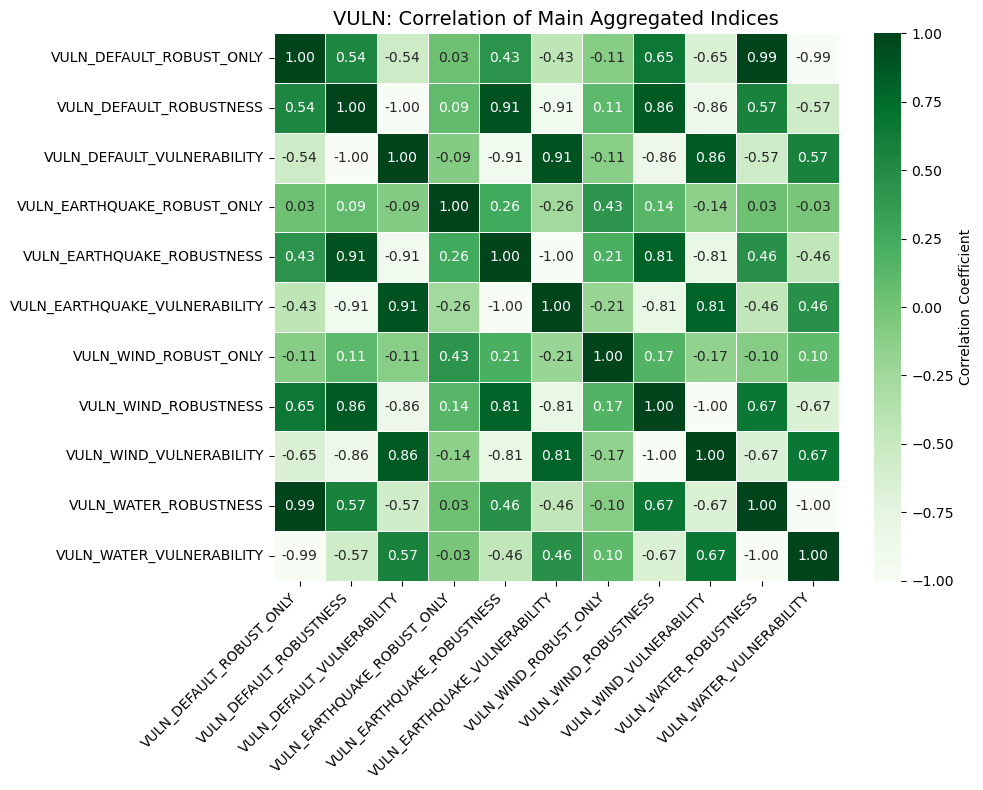


--- Correlation Matrix (Main VULN Indices Only) ---
                               VULN_DEFAULT_ROBUST_ONLY  \
VULN_DEFAULT_ROBUST_ONLY                           1.00   
VULN_DEFAULT_ROBUSTNESS                            0.54   
VULN_DEFAULT_VULNERABILITY                        -0.54   
VULN_EARTHQUAKE_ROBUST_ONLY                        0.03   
VULN_EARTHQUAKE_ROBUSTNESS                         0.43   
VULN_EARTHQUAKE_VULNERABILITY                     -0.43   
VULN_WIND_ROBUST_ONLY                             -0.11   
VULN_WIND_ROBUSTNESS                               0.65   
VULN_WIND_VULNERABILITY                           -0.65   
VULN_WATER_ROBUSTNESS                              0.99   
VULN_WATER_VULNERABILITY                          -0.99   

                               VULN_DEFAULT_ROBUSTNESS  \
VULN_DEFAULT_ROBUST_ONLY                          0.54   
VULN_DEFAULT_ROBUSTNESS                           1.00   
VULN_DEFAULT_VULNERABILITY                       -1.00   
VULN_E

In [44]:
print("\n" + "="*70)
print("⚙️ ステップ 1-2 FINAL FIX: VULN指標の集計と統合 (Water指標の計算堅牢化)")
print("======================================================")

# 0. 定数定義
HAZARDS_TO_INTEGRATE = ['FLOOD', 'STORM_SURGE', 'TSUNAMI']
INTEGRATED_WATER_HAZARD = 'WATER'

# VULN列のみを抽出し、コピーを作成
vuln_cols_raw = [col for col in df_analysis.columns if col.startswith('VULN_')]
df_vuln_processed = df_analysis[vuln_cols_raw].copy()

# 1. VULN列を確実に数値型に変換
for col in vuln_cols_raw:
    df_vuln_processed[col] = pd.to_numeric(df_vuln_processed[col], errors='coerce')


# 2. 集計インデックスの計算 (存在しない _ROBUST 列にも対応)
processed_types = set()
# 元のデータに存在するハザードタイプを抽出
vuln_pattern = re.compile(r'VULN_([A-Z_]+)_(FRAGILE|MEDIAN|ROBUST)$')
hazard_types_available = set()
for col in df_vuln_processed.columns:
    match = vuln_pattern.match(col)
    if match:
        hazard_types_available.add(match.group(1))

# 存在する全てのハザードタイプについて集計列を作成
for risk_type in sorted(list(hazard_types_available)):
    if risk_type in processed_types:
        continue

    fragile_col = f'VULN_{risk_type}_FRAGILE'
    median_col = f'VULN_{risk_type}_MEDIAN'
    robust_col = f'VULN_{risk_type}_ROBUST'

    # 2a. ROBUST_ONLY (純粋な堅牢性) 変数: ROBUST のみ
    robust_only_col_name = f'VULN_{risk_type}_ROBUST_ONLY'
    if robust_col in df_vuln_processed.columns:
        df_vuln_processed[robust_only_col_name] = df_vuln_processed[robust_col]

    # 2b. ROBUSTNESS (頑健性指数) 変数: MEDIAN + ROBUST
    robustness_col_name = f'VULN_{risk_type}_ROBUSTNESS'
    
    # 頑健性指数を計算するための列リスト（存在する列のみ）
    robustness_parts = []
    if median_col in df_vuln_processed.columns:
        robustness_parts.append(df_vuln_processed[median_col])
    if robust_col in df_vuln_processed.columns:
        robustness_parts.append(df_vuln_processed[robust_col])

    if robustness_parts:
        # 存在する列の合計を計算 (NaNは伝播するため、元の欠損値は維持される)
        # FLOOD/STORM_SURGE/TSUNAMIではROBUST列がないため、MEDIAN列のみの合計となる
        df_vuln_processed[robustness_col_name] = sum(robustness_parts)
    # 少なくとも MEDIAN または ROBUST が存在しない場合は、この列は作成されない

    # 2c. VULNERABILITY (脆弱性指数) 変数: FRAGILE only
    vulnerability_col_name = f'VULN_{risk_type}_VULNERABILITY'
    if fragile_col in df_vuln_processed.columns:
        df_vuln_processed[vulnerability_col_name] = df_vuln_processed[fragile_col]

    processed_types.add(risk_type)
print(f"Calculated aggregated indices for: {processed_types}")


# 3. Water Hazardsの統合 (FLOOD, STORM_SURGE, TSUNAMIの平均)
integrated_robustness_col = f'VULN_{INTEGRATED_WATER_HAZARD}_ROBUSTNESS'
integrated_vulnerability_col = f'VULN_{INTEGRATED_WATER_HAZARD}_VULNERABILITY'

# 3a. ROBUSTNESSの統合
robustness_cols_to_avg = [f'VULN_{h}_ROBUSTNESS' for h in HAZARDS_TO_INTEGRATE]
# 💡 FIX: df_vuln_processedに存在する列のみを選択してKeyErrorを回避
existing_robustness_cols = [col for col in robustness_cols_to_avg if col in df_vuln_processed.columns]

if existing_robustness_cols:
    # 存在する集計列の平均を計算
    df_vuln_processed[integrated_robustness_col] = df_vuln_processed[existing_robustness_cols].mean(axis=1)
else:
    # 統合の元となる列が一つもない場合は、全てNaNの列を作成
    df_vuln_processed[integrated_robustness_col] = np.nan

# 3b. VULNERABILITYの統合
vulnerability_cols_to_avg = [f'VULN_{h}_VULNERABILITY' for h in HAZARDS_TO_INTEGRATE]
# 💡 FIX: df_vuln_processedに存在する列のみを選択してKeyErrorを回避
existing_vulnerability_cols = [col for col in vulnerability_cols_to_avg if col in df_vuln_processed.columns]

if existing_vulnerability_cols:
    # 存在する集計列の平均を計算
    df_vuln_processed[integrated_vulnerability_col] = df_vuln_processed[existing_vulnerability_cols].mean(axis=1)
else:
    # 統合の元となる列が一つもない場合は、全てNaNの列を作成
    df_vuln_processed[integrated_vulnerability_col] = np.nan


# 4. 統合されたハザードの元の集計列を削除 (重複排除のため)
cols_to_drop_from_main = []
all_hazard_types = hazard_types_available.union(set(HAZARDS_TO_INTEGRATE))

for hazard in all_hazard_types:
    # 元の構成要素 (FRAGILE, MEDIAN, ROBUST) を削除
    for suffix in ['_FRAGILE', '_MEDIAN', '_ROBUST']:
        cols_to_drop_from_main.append(f'VULN_{hazard}{suffix}')
    
    # 統合されたハザード (FLOODなど) の集計指標も削除
    if hazard in HAZARDS_TO_INTEGRATE:
        for suffix in ['_ROBUSTNESS', '_VULNERABILITY', '_ROBUST_ONLY']:
             cols_to_drop_from_main.append(f'VULN_{hazard}{suffix}')

# 重複を削除し、df_analysisに存在する列のみを対象
cols_to_drop_final = [col for col in list(set(cols_to_drop_from_main)) if col in df_analysis.columns]
df_analysis.drop(columns=cols_to_drop_final, errors='ignore', inplace=True)
print(f"Dropped {len(cols_to_drop_final)} old/component VULN columns from df_analysis.")


# ----------------------------------------------------
# 📌 VULN集計指標のメインデータフレームへの統合 (Persistence)
# ----------------------------------------------------
print("--- 🔧 VULN集計指標のメインデータフレームへの統合 ---")
# df_vuln_processed に含まれる新しいVULN指標を df_analysis に追加します。
new_agg_cols_pattern = r'VULN_[A-Z_]+_(ROBUSTNESS|VULNERABILITY|ROBUST_ONLY)$'
cols_to_merge = [col for col in df_vuln_processed.columns if re.match(new_agg_cols_pattern, col)]

# df_analysisに存在しない列のみを追加
new_cols_added = []
for col in cols_to_merge:
    if col not in df_analysis.columns:
        df_analysis[col] = df_vuln_processed[col]
        new_cols_added.append(col)
        
        # メタデータも更新
        if col not in COLUMN_METADATA_LOADED:
            hazard_name = col.split('_')[1]
            if 'ROBUSTNESS' in col:
                COLUMN_METADATA_LOADED[col] = f'Aggregated Building Robustness Index for {hazard_name} (MEDIAN + ROBUST)'
            elif 'VULNERABILITY' in col:
                COLUMN_METADATA_LOADED[col] = f'Aggregated Building Vulnerability Index for {hazard_name} (FRAGILE only)'
            elif 'ROBUST_ONLY' in col:
                COLUMN_METADATA_LOADED[col] = f'Aggregated Building Robustness Index for {hazard_name} (ROBUST only)'

print(f"Merged {len(new_cols_added)} new aggregated VULN indices into df_analysis: {new_cols_added}")



# 5. 相関分析の準備 (主要指標のみ)
print("--- 5. Preparing Correlation Analysis for Main Indices ---")
# 相関分析に含める主要な集計指標のみを選択
main_indices_pattern = r'VULN_(DEFAULT|EARTHQUAKE|WIND|WATER)_(ROBUSTNESS|VULNERABILITY|ROBUST_ONLY)$'
cols_for_analysis = [col for col in df_analysis.columns if re.match(main_indices_pattern, col)]

# df_analysis から最新のデータを取得
df_vuln_main_indices = df_analysis[cols_for_analysis].copy()

# 6. 相関行列の計算と可視化 (主要指標のみ)
correlation_matrix_main = df_vuln_main_indices.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix_main,
    annot=True,
    cmap='Greens',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('VULN: Correlation of Main Aggregated Indices', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. 相関結果の表示 (主要指標のみ)
print("\n--- Correlation Matrix (Main VULN Indices Only) ---")
print(correlation_matrix_main.round(2))
print("---------------------------------------")

print("\n✅ Step 1-2 (VULN Aggregation & Integration) is complete.")

## MPI

🧹 データクレンジング: 'NUL'エラーの修正
✅ クレンジング完了。非標準の'NUL'値はNaNに変換されました。

📈 ステップ 1-3: MPI Data (多次元貧困) 相関分析 (再実行)


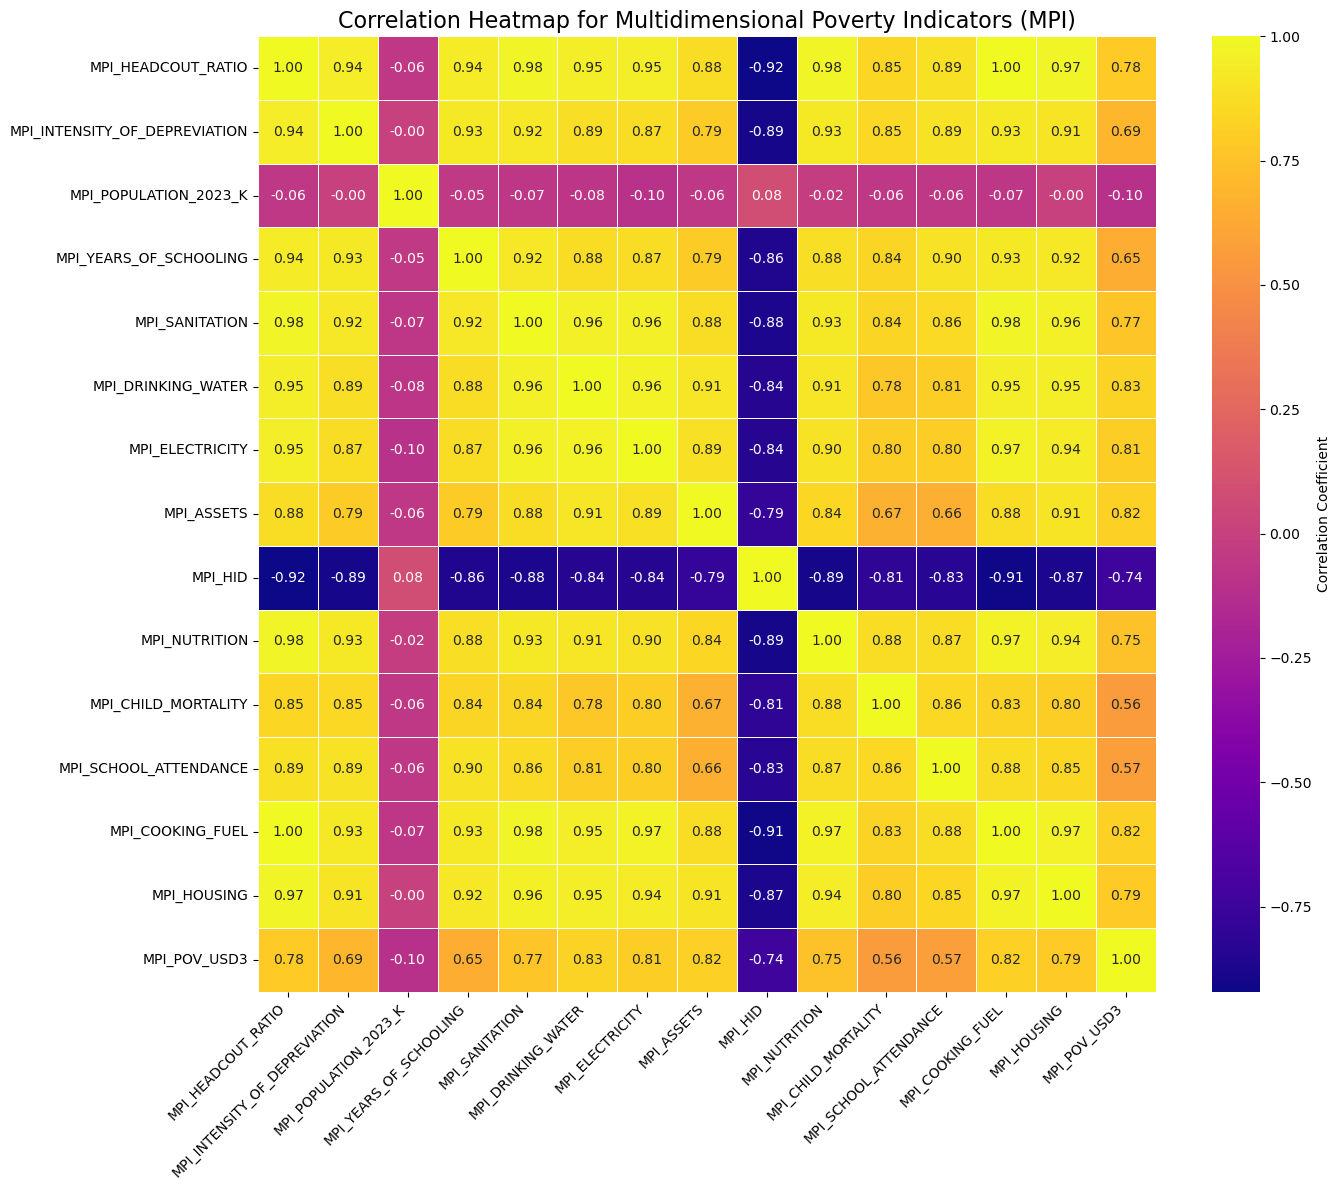


--- 相関行列（MPI Data） ---
                               MPI_HEADCOUT_RATIO  \
MPI_HEADCOUT_RATIO                           1.00   
MPI_INTENSITY_OF_DEPREVIATION                0.94   
MPI_POPULATION_2023_K                       -0.06   
MPI_YEARS_OF_SCHOOLING                       0.94   
MPI_SANITATION                               0.98   
MPI_DRINKING_WATER                           0.95   
MPI_ELECTRICITY                              0.95   
MPI_ASSETS                                   0.88   
MPI_HID                                     -0.92   
MPI_NUTRITION                                0.98   
MPI_CHILD_MORTALITY                          0.85   
MPI_SCHOOL_ATTENDANCE                        0.89   
MPI_COOKING_FUEL                             1.00   
MPI_HOUSING                                  0.97   
MPI_POV_USD3                                 0.78   

                               MPI_INTENSITY_OF_DEPREVIATION  \
MPI_HEADCOUT_RATIO                                      0.94   

In [45]:

print("="*60)
print("🧹 データクレンジング: 'NUL'エラーの修正")
print("="*60)

# 1. MPI指標の列を特定
mpi_numeric_cols = [
    'MPI', 'Headcout ratio', 'Intensity of depreviation', 
    'Population_2023_k', 'Years of schooling', 'Sanitation', 
    'Drinking water', 'Electricity', 'Assets', 'Nutrition', 
    'Child mortality', 'School attendance', 'Cooking fuel', 
    'Housing', 'Monetary poverty _USD3', 'GNI_PC', 'HID'
]
# クリーンアップ後の列名（MPI_プレフィックス付き）を使用
mpi_cols_to_clean = [f'MPI_{col}'.replace(' ', '_').replace('__', '_').replace('MONETARY_POVERTY__USD3', 'POV_USD3') for col in mpi_numeric_cols]
# df_analysisに実際に存在する列名（以前のステップで既にクリーンアップされていると仮定）
mpi_cols_present = [col for col in df_analysis.columns if col.startswith('MPI_') and col not in ['MPI_WORLD_REGION', 'MPI_SURVEY', 'MPI_YEAR', 'MPI_INCOME_CATEGORY']]


# 2. 非標準の欠損値マーカーを標準のNaNに置き換え
# 影響のある列すべてに対して処理を実行します。
for col in mpi_cols_present:
    # 'NUL'文字列をNaNに置き換え
    df_analysis[col] = df_analysis[col].replace('NUL', np.nan)
    
    # データ型を確実に数値型（float）に変換
    # errors='coerce' は、変換できない値（もしあれば）をNaNに置き換えます
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')


print("✅ クレンジング完了。非標準の'NUL'値はNaNに変換されました。")


# ----------------------------------------------------
# 📈 ステップ 1-3: MPI Data (多次元貧困) 相関分析 (再実行)
# ----------------------------------------------------

print("\n" + "="*60)
print("📈 ステップ 1-3: MPI Data (多次元貧困) 相関分析 (再実行)")
print("="*60)

df_mpi = df_analysis[mpi_cols_present].copy()

# 相関行列の計算（NaNは無視してペアワイズ処理）
correlation_matrix_mpi = df_mpi.corr()

# 3. 相関ヒートマップの可視化
plt.figure(figsize=(14, 12)) 
sns.heatmap(
    correlation_matrix_mpi,
    annot=True,             
    cmap='plasma',          
    fmt=".2f",              
    linewidths=.5,          
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Heatmap for Multidimensional Poverty Indicators (MPI)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show() 

# 4. 相関結果の表示（任意）
print("\n--- 相関行列（MPI Data） ---")
print(correlation_matrix_mpi.round(2))
print("-----------------------------------")

## WB data 


📈 ステップ 1-4  World Bank (WB) 経済指標の相関分析


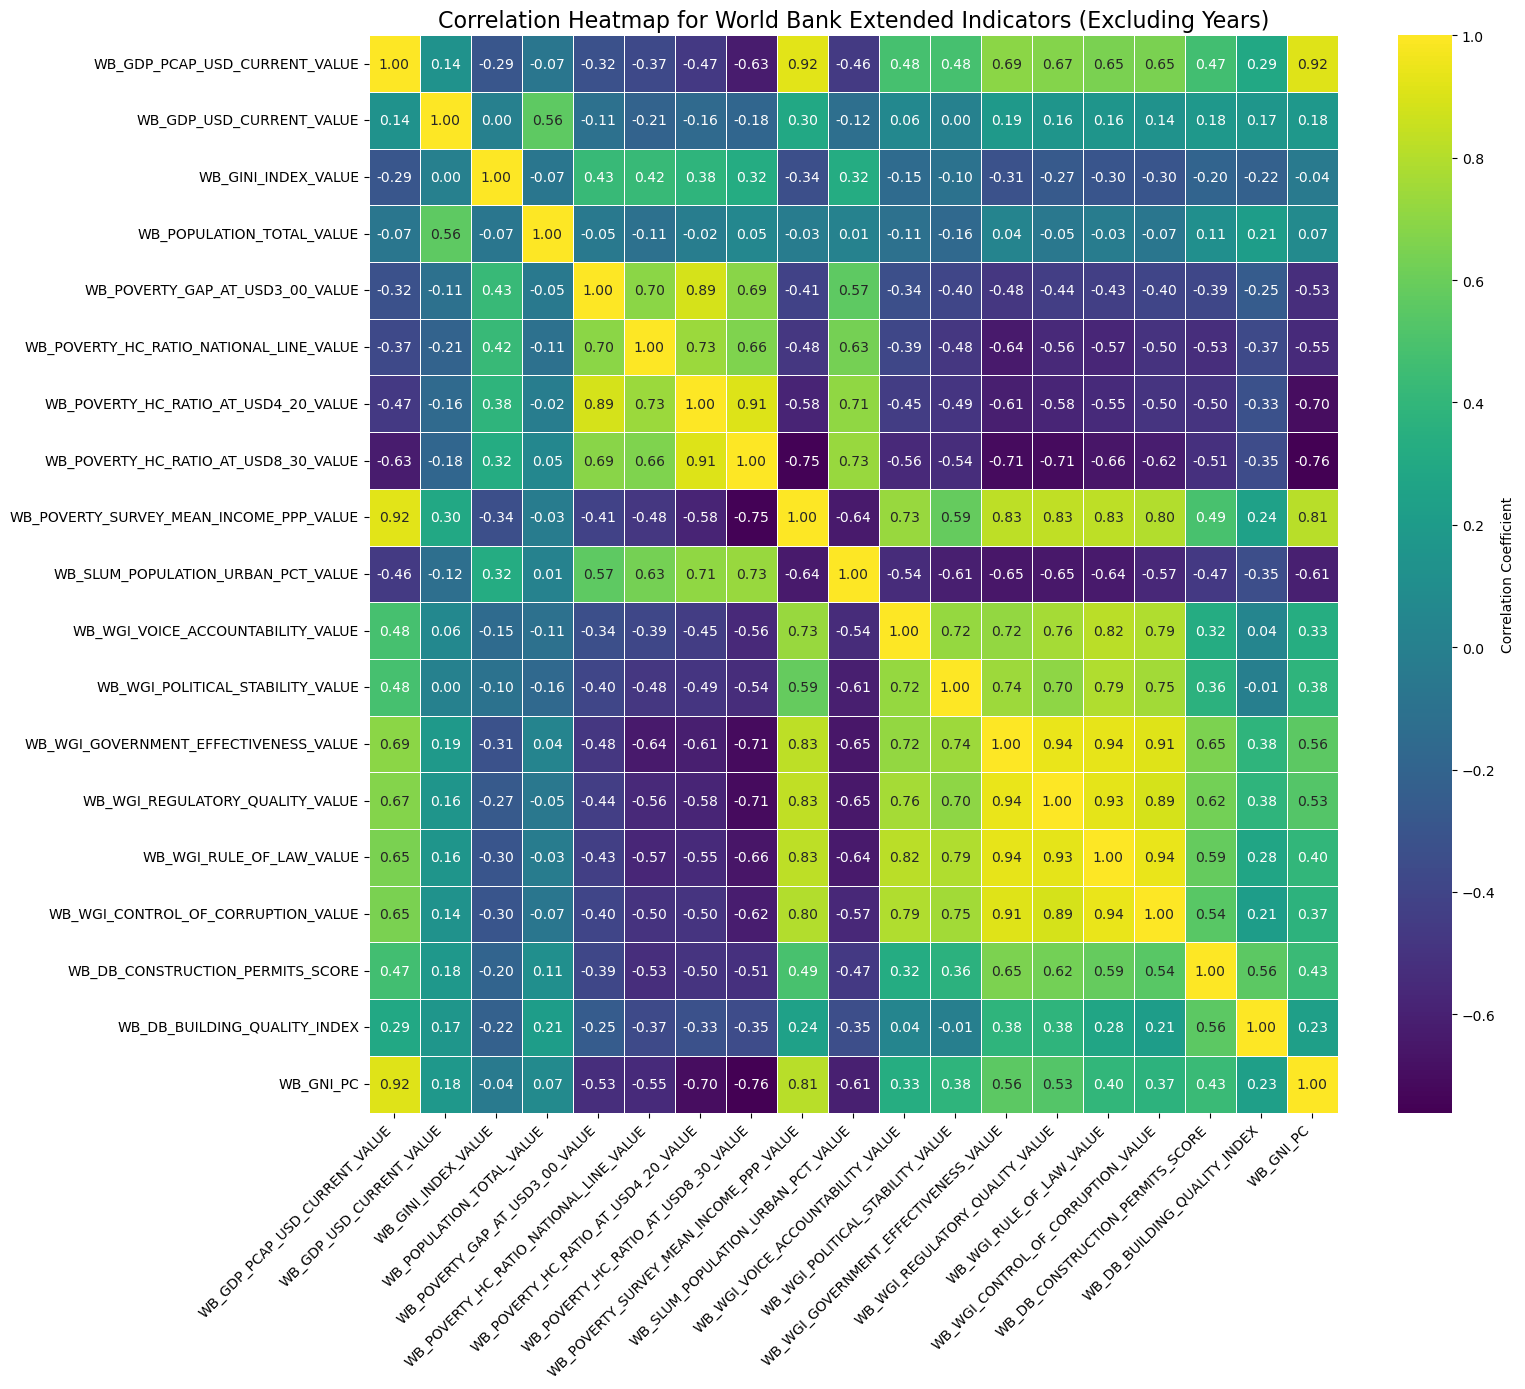


--- 相関行列（World Bank Extended Data - YEAR列除外） ---
                                         WB_GDP_PCAP_USD_CURRENT_VALUE  \
WB_GDP_PCAP_USD_CURRENT_VALUE                                     1.00   
WB_GDP_USD_CURRENT_VALUE                                          0.14   
WB_GINI_INDEX_VALUE                                              -0.29   
WB_POPULATION_TOTAL_VALUE                                        -0.07   
WB_POVERTY_GAP_AT_USD3_00_VALUE                                  -0.32   
WB_POVERTY_HC_RATIO_NATIONAL_LINE_VALUE                          -0.37   
WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE                             -0.47   
WB_POVERTY_HC_RATIO_AT_USD8_30_VALUE                             -0.63   
WB_POVERTY_SURVEY_MEAN_INCOME_PPP_VALUE                           0.92   
WB_SLUM_POPULATION_URBAN_PCT_VALUE                               -0.46   
WB_WGI_VOICE_ACCOUNTABILITY_VALUE                                 0.48   
WB_WGI_POLITICAL_STABILITY_VALUE                              

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------
# ⚠️ 注意: このコードは 'df_analysis' が既に定義されていることを前提とします。
# ----------------------------------------------------

print("\n" + "="*70)
print("📈 ステップ 1-4  World Bank (WB) 経済指標の相関分析")
print("======================================================")

# 1. WB指標の列を抽出
wb_cols_all = [col for col in df_analysis.columns if col.startswith('WB_')]

# 数値の「Value」列、および「YEAR」を含まない列を選択するロジックを修正
wb_numeric_cols = []
for col in wb_cols_all:
    # 1. 'VALUE' または 'PC' を含む列 (時系列データ)
    if ('VALUE' in col or 'PC' in col) and ('YEAR' not in col):
        wb_numeric_cols.append(col)
        
    # 2. 'DB_' で始まる列 (DB指標は 'VALUE' サフィックスがないため、個別に抽出)
    elif col.startswith('WB_DB_'):
        wb_numeric_cols.append(col)

# df_analysisに実際に存在する列のみを抽出
wb_cols_present = [col for col in wb_numeric_cols if col in df_analysis.columns]

# DB Construction指標が含まれていることを確認
db_check = [col for col in wb_cols_present if col.startswith('WB_DB_')]
if not db_check:
    print("\n⚠️ 警告: Doing Business (DB) Construction 指標がデータフレームに見つかりませんでした。データ統合の再確認が必要です。")

df_wb = df_analysis[wb_cols_present].copy()

# 2. クレンジングとデータ型の保証
# 非標準の欠損値（'NUL'）をNaNに変換し、データ型を数値型に統一
# (注: 'NUL' は以前の処理で排除されているはずですが、堅牢性のために残します)
for col in df_wb.columns:
    df_wb[col] = df_wb[col].replace('NUL', np.nan)
    df_wb[col] = pd.to_numeric(df_wb[col], errors='coerce')

# 3. 相関行列の計算
correlation_matrix_wb = df_wb.corr()

# 4. 相関ヒートマップの可視化
plt.figure(figsize=(16, 14)) 
sns.heatmap(
    correlation_matrix_wb,
    annot=True,              
    cmap='viridis',          # 'cividis'でも良いですが、'viridis'系のほうがコントラストが高い場合があります
    fmt=".2f",               
    linewidths=.5,           
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Heatmap for World Bank Extended Indicators (Excluding Years)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show() 


# 5. 相関結果の表示
print("\n--- 相関行列（World Bank Extended Data - YEAR列除外） ---")
print(correlation_matrix_wb.round(2))
print("-----------------------------------")

print("\n✅ WBデータ分析が、Doing Business指標を含め、YEAR列を除外した正しい形式で再実行されました。")

## Check data 

In [47]:
# ----------------------------------------------------
# 📊 ステップ 1-5 (確認のために再表示するロジック) - 記述統計を追加
# ----------------------------------------------------
print("--- 🔬 記述統計情報とOutlier可能性のチェック ---")

# 1. データフレームの列名とデータ型、有効なカウントを取得
column_info = df_analysis.dtypes.reset_index()
column_info.columns = ['Variable Name', 'Data Type']
valid_counts = df_analysis.count().reset_index()
valid_counts.columns = ['Variable Name', 'Valid Count']

# --- NEW: 記述統計の計算 ---
# 数値列のみを選択し、describe()を実行
numeric_cols = df_analysis.select_dtypes(include=np.number).columns
if not numeric_cols.empty:
    descriptive_stats = df_analysis[numeric_cols].describe(
        percentiles=[.25, .5, .75]
    ).T.reset_index()
    descriptive_stats.columns = [
        'Variable Name', 'Count', 'Mean', 'Std', 'Min', 'Q1 (25%)', 'Median (50%)', 'Q3 (75%)', 'Max'
    ]
    # 'Count'列は'Valid Count'と重複するため削除
    descriptive_stats.drop(columns=['Count'], inplace=True)
else:
    # 数値列がない場合のダミーデータフレーム
    descriptive_stats = pd.DataFrame({'Variable Name': [], 'Min': [], 'Max': []})


# 2. メタデータと結合
metadata_df = pd.DataFrame(COLUMN_METADATA_LOADED.items(), columns=['Variable Name', 'Description'])
integrated_list = pd.merge(column_info, valid_counts, on='Variable Name', how='left')
integrated_list = pd.merge(integrated_list, metadata_df, on='Variable Name', how='left')

# --- NEW: 記述統計を結合 ---
# 統計量は数値列にしか存在しないため、左結合（how='left'）
integrated_list = pd.merge(integrated_list, descriptive_stats, on='Variable Name', how='left')


# 3. 表示用にデータ型、説明を整理
integrated_list['Description'] = integrated_list['Description'].fillna('❌ Description Not Found in JSON')
integrated_list['Data Type'] = integrated_list['Data Type'].astype(str)

print("\n" + "="*150)
print(f"✅ 📊 統合変数リストと記述統計 (Outlier可能性チェック) (Total Observations: {len(df_analysis)})")
print("="*150)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    # 'Valid Count'でソートし、欠損が多い順（データが少ない順）に確認できるようにします
    # float_format='{:.2f}'.format で、数値列の表示を小数点以下2桁に整形します
    print(integrated_list.sort_values(by='Valid Count', ascending=True).to_string(index=False, float_format='{:.2f}'.format))

print("="*150)
print("Note: Outlierの可能性は、Min/MaxとQ1/Q3からの乖離（IQRの1.5倍超）で判断されます。")
print("======================================================================================================================================================")

--- 🔬 記述統計情報とOutlier可能性のチェック ---

✅ 📊 統合変数リストと記述統計 (Outlier可能性チェック) (Total Observations: 217)
                          Variable Name Data Type  Valid Count                                                            Description            Mean              Std         Min      Q1 (25%)   Median (50%)        Q3 (75%)               Max
                          MPI_NUTRITION   float64           98                         Percentage of people deprived in nutrition - %           13.44            13.83        0.02          1.16           7.40           26.39             50.60
                       MPI_COOKING_FUEL   float64          102                      Percentage of people deprived in cooking fuel - %           22.38            24.95        0.00          0.99          10.29           41.32             82.01
                           MPI_POV_USD3   float64          105                              Poverty rate at $3 a day (MPI Source) - %           20.57            23.17        0.00  

In [48]:
# --------------------------------------------------------------------------------------
# 📈 Step 7: Poverty Headcount Ratio Test
# --------------------------------------------------------------------------------------
# 目的:
# Slum Pop (WB_SLUM_POPULATION_URBAN_PCT_VALUE)を、
# より一般的な貧困指標である Poverty Headcount Ratio at $4.20 PPP/day 
# (WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE) に置き換えてモデルを再実行し、
# どちらの指標がロバストネスの変動により強い説明力を持つかを比較する。
# --------------------------------------------------------------------------------------

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# NOTE: df_analysis の定義が必要です。

print("\n" + "="*70)
print("📈 STARTING Step 7: Poverty Headcount Ratio Test")
print("Target Y: VULN_DEFAULT_ROBUSTNESS")
print("X Factors: Poverty HC ($4.20/day), Gov Effective, Building Quality")
print("="*70)

# --- 1. 変数の定義とクリーニング ---
Y_VAR = 'VULN_DEFAULT_ROBUSTNESS'

# Slum Pop を所得貧困率に置き換える
X_VARS_NEW_POVERTY = [
    'WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE',  # 新しい貧困指標
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
    'WB_DB_BUILDING_QUALITY_INDEX',
]

# モデルに使用するデータセットの準備
df_model = df_analysis[[Y_VAR] + X_VARS_NEW_POVERTY].copy()

for col in df_model.columns:
    df_model[col] = df_model[col].replace('NUL', np.nan)
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# 欠損値を含む行を除外 (リストワイズで除外)
df_clean = df_model.dropna()
n_obs = df_clean.shape[0]

# 観測数がどのように変化したか確認
print(f"✅ モデル構築のための有効な観測数 N: {n_obs}")

# --- 2. モデルの実行 ---
if n_obs > 100:
    Y = df_clean[Y_VAR]
    X = df_clean[X_VARS_NEW_POVERTY]
    X = sm.add_constant(X) # 切片 (constant) を追加

    # OLS (最小二乗法) モデルの構築
    model = sm.OLS(Y, X).fit()

    # 結果の表示
    print("\n" + "-"*25 + " Multiple Regression Results (Poverty HC Model) " + "-"*25)
    print(model.summary())
    print("-"*(60 + 11))

    # --- 3. 多重共線性 (VIF) のチェック ---
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    print("\n" + "-"*30 + " Variance Inflation Factor (VIF) " + "-"*30)
    print(vif_data[vif_data['Variable'] != 'const'].round(2))
    print("-"*(60 + 11))

    # --- 4. 結果の簡単な考察 ---
    r_squared = model.rsquared
    
    print("\n--- Summary of Poverty HC Model Assessment ---")
    print(f"R-squared (決定係数): {r_squared:.3f} -> Slum Popモデル (0.477)と比較してください。")
    print("--------------------------------------------")
else:
    print("❌ 観測数が少なすぎるため、モデルを構築できませんでした。")


📈 STARTING Step 7: Poverty Headcount Ratio Test
Target Y: VULN_DEFAULT_ROBUSTNESS
X Factors: Poverty HC ($4.20/day), Gov Effective, Building Quality
✅ モデル構築のための有効な観測数 N: 159

------------------------- Multiple Regression Results (Poverty HC Model) -------------------------
                               OLS Regression Results                              
Dep. Variable:     VULN_DEFAULT_ROBUSTNESS   R-squared:                       0.506
Model:                                 OLS   Adj. R-squared:                  0.496
Method:                      Least Squares   F-statistic:                     52.86
Date:                     Mon, 10 Nov 2025   Prob (F-statistic):           1.38e-23
Time:                             10:44:25   Log-Likelihood:                 32.698
No. Observations:                      159   AIC:                            -57.40
Df Residuals:                          155   BIC:                            -45.12
Df Model:                                3           

In [49]:
# --------------------------------------------------------------------------------------
# 📈 Step 8: Major Determinants Integrated Model (Wide Approach)
# --------------------------------------------------------------------------------------
# 目的:
# 貧困、ガバナンス、建築インフラ、富（GDP per capita）といった主要な
# 構造的決定要因を全て同時に投入し、各変数の独立した説明力を確認する。
# 多重共線性 (VIF) を確認し、どの変数が「本質的な」ドライバーであるかを特定する。
# --------------------------------------------------------------------------------------

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# NOTE: df_analysis の定義が必要です。

print("\n" + "="*70)
print("📈 STARTING Step 8: Major Determinants Integrated Model")
print("Target Y: VULN_DEFAULT_ROBUSTNESS")
print("X Factors: Poverty HC ($4.20/day), Gov Effective, Building Quality, GDP per capita")
print("="*70)

# --- 1. 変数の定義とクリーニング ---
Y_VAR = 'VULN_DEFAULT_ROBUSTNESS'

# 主要な説明変数を統合
X_VARS_INTEGRATED = [
    'WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE',    # 所得貧困率
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',   # 政府の有効性
    'WB_DB_BUILDING_QUALITY_INDEX',            # 建築品質
    'WB_GDP_PCAP_USD_CURRENT_VALUE',           # 一人当たりGDP
]

# モデルに使用するデータセットの準備
df_model = df_analysis[[Y_VAR] + X_VARS_INTEGRATED].copy()

for col in df_model.columns:
    df_model[col] = df_model[col].replace('NUL', np.nan)
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# 欠損値を含む行を除外 (リストワイズで除外)
df_clean = df_model.dropna()
n_obs = df_clean.shape[0]

# 観測数がどのように変化したか確認
print(f"✅ モデル構築のための有効な観測数 N: {n_obs}")

# --- 2. モデルの実行 ---
if n_obs > 100:
    # データが広範囲にわたるため、一人当たりGDPを対数変換して分散を抑える
    df_clean['LOG_GDP_PCAP'] = np.log1p(df_clean['WB_GDP_PCAP_USD_CURRENT_VALUE'])
    
    X_VARS_FINAL = [
        'WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE',
        'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
        'WB_DB_BUILDING_QUALITY_INDEX',
        'LOG_GDP_PCAP', # 対数変換したGDP per capitaを使用
    ]

    Y = df_clean[Y_VAR]
    X = df_clean[X_VARS_FINAL]
    X = sm.add_constant(X) # 切片 (constant) を追加

    # OLS (最小二乗法) モデルの構築
    model = sm.OLS(Y, X).fit()

    # 結果の表示
    print("\n" + "-"*25 + " Multiple Regression Results (Integrated Model) " + "-"*25)
    print(model.summary())
    print("-"*(60 + 11))

    # --- 3. 多重共線性 (VIF) のチェック ---
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    print("\n" + "-"*30 + " Variance Inflation Factor (VIF) " + "-"*30)
    # VIF > 5.0 は多重共線性の懸念があると見なされます。
    print(vif_data[vif_data['Variable'] != 'const'].round(2))
    print("-"*(60 + 11))

    # --- 4. 結果の簡単な考察 ---
    r_squared = model.rsquared
    
    print("\n--- Summary of Integrated Model Assessment ---")
    print(f"R-squared (決定係数): {r_squared:.3f}")
    print("--------------------------------------------")
else:
    print("❌ 観測数が少なすぎるため、モデルを構築できませんでした。")


📈 STARTING Step 8: Major Determinants Integrated Model
Target Y: VULN_DEFAULT_ROBUSTNESS
X Factors: Poverty HC ($4.20/day), Gov Effective, Building Quality, GDP per capita
✅ モデル構築のための有効な観測数 N: 159

------------------------- Multiple Regression Results (Integrated Model) -------------------------
                               OLS Regression Results                              
Dep. Variable:     VULN_DEFAULT_ROBUSTNESS   R-squared:                       0.515
Model:                                 OLS   Adj. R-squared:                  0.503
Method:                      Least Squares   F-statistic:                     40.91
Date:                     Mon, 10 Nov 2025   Prob (F-statistic):           2.51e-23
Time:                             10:44:25   Log-Likelihood:                 34.239
No. Observations:                      159   AIC:                            -58.48
Df Residuals:                          154   BIC:                            -43.13
Df Model:                     

C:\Users\wb512463\AppData\Local\Temp\ipykernel_23204\2077176516.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['LOG_GDP_PCAP'] = np.log1p(df_clean['WB_GDP_PCAP_USD_CURRENT_VALUE'])


In [50]:
# --------------------------------------------------------------------------------------
# 📈 Step 9: Final Parsimonious Model (Poverty & Wealth)
# --------------------------------------------------------------------------------------
# 目的:
# Step 8で非有意となった変数 (Gov Effective, Building Quality) を削除し、
# 最も有意かつ本質的な二大要因 (Poverty HC と LOG_GDP_PCAP) のみに絞り、
# 最終的な最良モデルを確定する。
# --------------------------------------------------------------------------------------

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# NOTE: df_analysis の定義が必要です。

print("\n" + "="*70)
print("📈 STARTING Step 9: Final Parsimonious Model")
print("Target Y: VULN_DEFAULT_ROBUSTNESS")
print("X Factors: Poverty HC ($4.20/day) and LOG_GDP_PCAP")
print("="*70)

# --- 1. 変数の定義とクリーニング ---
Y_VAR = 'VULN_DEFAULT_ROBUSTNESS'

# 最終モデルに残す変数を定義
X_VARS_PARSIMONIOUS = [
    'WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE',    # 所得貧困率
    'WB_GDP_PCAP_USD_CURRENT_VALUE',           # 一人当たりGDP (対数変換前)
]

# モデルに使用するデータセットの準備
df_model = df_analysis[[Y_VAR] + X_VARS_PARSIMONIOUS].copy()

for col in df_model.columns:
    df_model[col] = df_model[col].replace('NUL', np.nan)
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# 欠損値を含む行を除外 (リストワイズで除外)
df_clean = df_model.dropna()
n_obs = df_clean.shape[0]

# 観測数がどのように変化したか確認 (Step 7/8と同じ159であるはず)
print(f"✅ モデル構築のための有効な観測数 N: {n_obs}")

# --- 2. モデルの実行 ---
if n_obs > 100:
    # 一人当たりGDPを対数変換
    df_clean['LOG_GDP_PCAP'] = np.log1p(df_clean['WB_GDP_PCAP_USD_CURRENT_VALUE'])
    
    X_VARS_FINAL = [
        'WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE',
        'LOG_GDP_PCAP', # 対数変換したGDP per capitaを使用
    ]

    Y = df_clean[Y_VAR]
    X = df_clean[X_VARS_FINAL]
    X = sm.add_constant(X) # 切片 (constant) を追加

    # OLS (最小二乗法) モデルの構築
    model = sm.OLS(Y, X).fit()

    # 結果の表示
    print("\n" + "-"*25 + " OLS Regression Results (Final Model) " + "-"*25)
    print(model.summary())
    print("-"*(60 + 11))

    # --- 3. 多重共線性 (VIF) のチェック ---
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    # VIF計算は切片を除外して行う
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    print("\n" + "-"*30 + " Variance Inflation Factor (VIF) " + "-"*30)
    print(vif_data[vif_data['Variable'] != 'const'].round(2))
    print("-"*(60 + 11))

    # --- 4. 結果の簡単な考察 ---
    r_squared = model.rsquared
    
    print("\n--- Summary of Final Model Assessment ---")
    print(f"R-squared (決定係数): {r_squared:.3f}")
    print("--------------------------------------------")
else:
    print("❌ 観測数が少なすぎるため、モデルを構築できませんでした。")


📈 STARTING Step 9: Final Parsimonious Model
Target Y: VULN_DEFAULT_ROBUSTNESS
X Factors: Poverty HC ($4.20/day) and LOG_GDP_PCAP
✅ モデル構築のための有効な観測数 N: 170

------------------------- OLS Regression Results (Final Model) -------------------------
                               OLS Regression Results                              
Dep. Variable:     VULN_DEFAULT_ROBUSTNESS   R-squared:                       0.490
Model:                                 OLS   Adj. R-squared:                  0.484
Method:                      Least Squares   F-statistic:                     80.36
Date:                     Mon, 10 Nov 2025   Prob (F-statistic):           3.57e-25
Time:                             10:44:25   Log-Likelihood:                 33.046
No. Observations:                      170   AIC:                            -60.09
Df Residuals:                          167   BIC:                            -50.68
Df Model:                                2                                         

C:\Users\wb512463\AppData\Local\Temp\ipykernel_23204\3499489150.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['LOG_GDP_PCAP'] = np.log1p(df_clean['WB_GDP_PCAP_USD_CURRENT_VALUE'])


# Step 2. Correlation of indicator among different databases

In [51]:
# --------------------------------------------------------------------------------------
# 🔬 Step 2: Correlation Analysis of Resilience Factors (Based on Primary Objectives)
# --------------------------------------------------------------------------------------
# NOTE: Before running this code block, ensure that:
# df_analysis (the DataFrame) and the necessary libraries (pd, np, plt, sns) are defined.
# --------------------------------------------------------------------------------------

print("\n" + "="*70)
print("🔬 STARTING Step 2: Correlation Analysis of Resilience Factors")
print("="*70)

# Function to efficiently perform correlation analysis
def run_correlation_analysis(df, correlation_group_name, variable_groups):
    """
    Executes correlation analysis between specified variable groups and displays a heatmap.
    
    MODIFICATION 2 (NUL Fix):
    - Added an internal cleaning step to ensure all selected columns are converted
      to numeric type *before* correlation, removing 'NUL' strings.
    """
    # Flatten the list of variables and select only columns that exist in the DataFrame
    all_vars = [v for sublist in variable_groups.values() for v in sublist]
    cols_for_corr = [col for col in all_vars if col in df.columns]

    if not cols_for_corr:
        print(f"⚠️ WARNING: No required columns found for the correlation group: {correlation_group_name}. Skipping.")
        return

    df_corr = df[cols_for_corr].copy()

    # --- 💡 NEW (FIX): Data Cleaning Step ---
    # Ensure all columns are numeric, converting 'NUL' and other errors to NaN
    # This specifically fixes the ValueError for MPI columns.
    for col in df_corr.columns:
        # 1. Replace the string 'NUL' with a standard NaN
        df_corr[col] = df_corr[col].replace('NUL', np.nan)
        # 2. Convert the entire column to numeric, coercing errors
        df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')
    # --- End of Cleaning Step ---

    # Calculate the correlation matrix (ignoring NaN pairwise)
    correlation_matrix = df_corr.corr()

    # --- Calculate the Pairwise N Count Matrix ---
    df_notna = df_corr.notna().astype(int)
    n_matrix = df_notna.T.dot(df_notna)

    # Get the number of countries/rows that have at least ONE valid data point
    valid_n_total = df_corr.dropna(how='all').shape[0]

    # Visualize the heatmap
    plt.figure(figsize=(len(cols_for_corr) * 0.8, len(cols_for_corr) * 0.7))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap='vlag', # Diverging color map
        fmt=".2f",
        linewidths=.5,
        cbar_kws={'label': 'Correlation Coefficient'}
    )
    plt.title(f'Correlation Heatmap: {correlation_group_name} (N up to {valid_n_total})', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Display the correlation matrix results
    print(f"\n--- Correlation Matrix: {correlation_group_name} ---")
    print(correlation_matrix.round(2))
    print("-----------------------------------")

    # Display the Pairwise N Count Matrix
    print(f"\n--- Pairwise Valid N Count Matrix: {correlation_group_name} ---")
    print(n_matrix)
    print("-----------------------------------")

# --- EXPANDED ROBUSTNESS VARIABLE LIST (Applied to all groups A, B, C) ---
# これにより、ROBUSTNESS (総合指標) と ROBUST_ONLY (建築規定のみの指標) の両方を比較できます。
expanded_robustness_vars = [
    'VULN_DEFAULT_ROBUST_ONLY',
    'VULN_DEFAULT_ROBUSTNESS',
    'VULN_EARTHQUAKE_ROBUST_ONLY',
    'VULN_EARTHQUAKE_ROBUSTNESS',
    'VULN_WIND_ROBUST_ONLY',
    'VULN_WIND_ROBUSTNESS',
    'VULN_WATER_ROBUSTNESS' # VULN_WATER_ROBUST_ONLY はデータに存在しないため含めない
]


🔬 STARTING Step 2: Correlation Analysis of Resilience Factors


## Governance vs Building Robustness

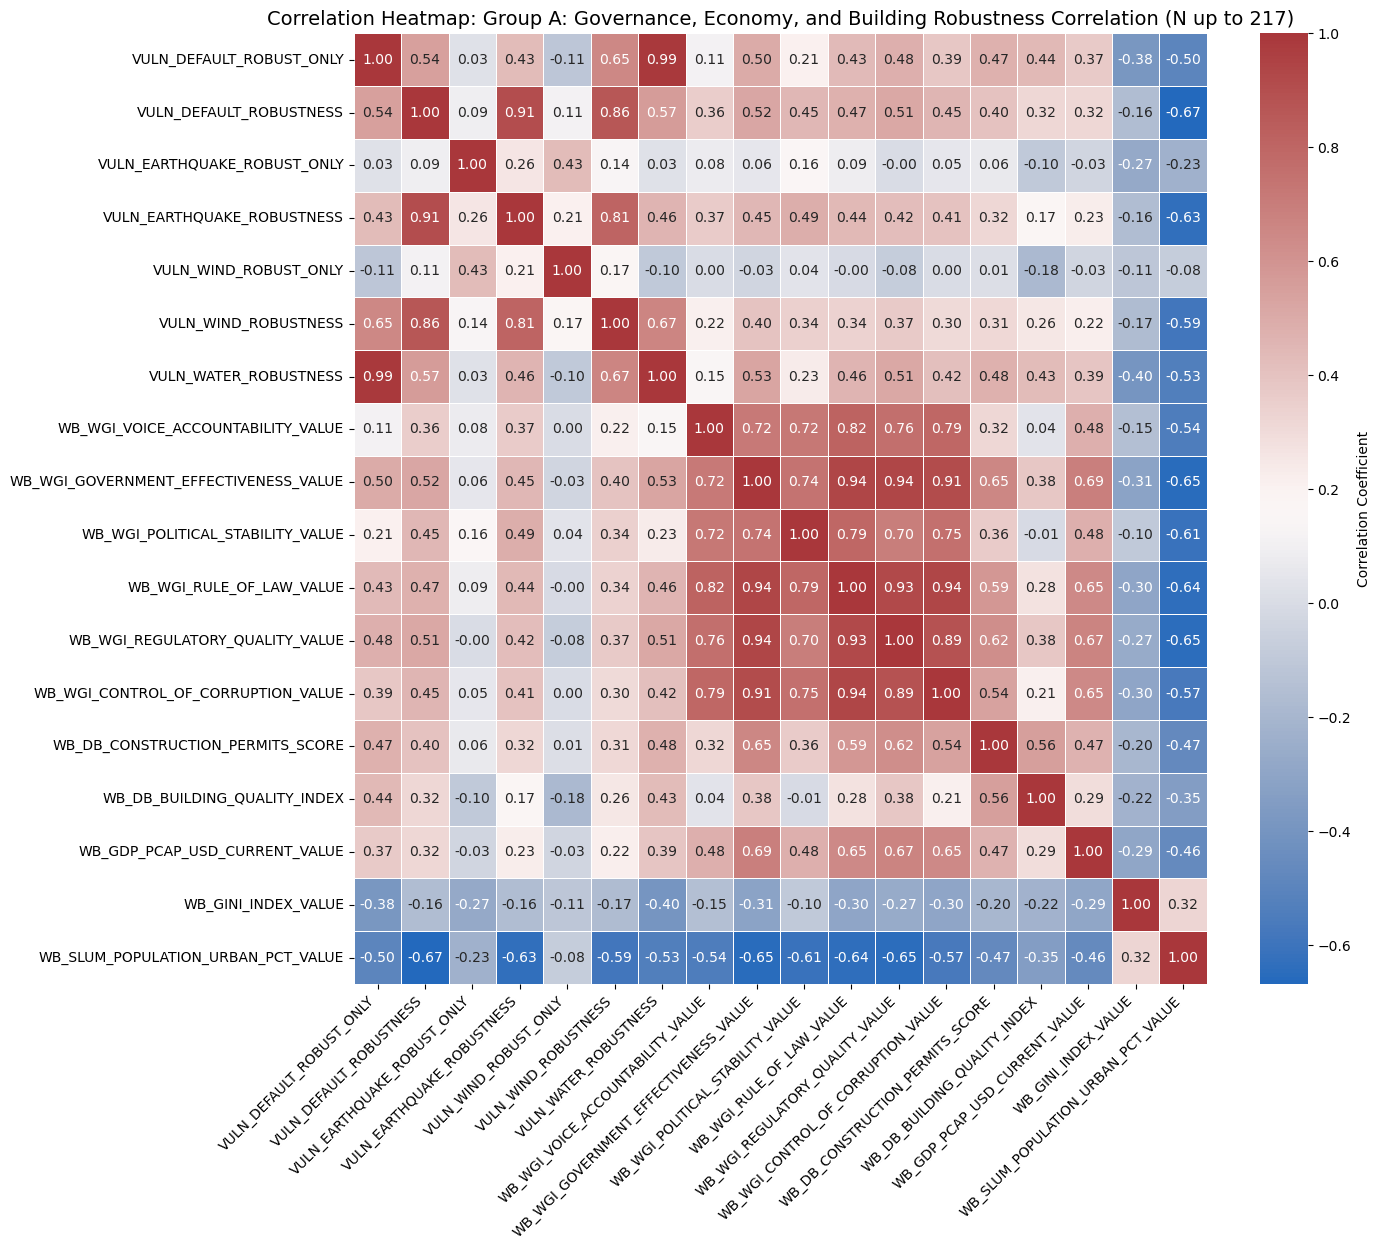


--- Correlation Matrix: Group A: Governance, Economy, and Building Robustness Correlation ---
                                       VULN_DEFAULT_ROBUST_ONLY  \
VULN_DEFAULT_ROBUST_ONLY                                   1.00   
VULN_DEFAULT_ROBUSTNESS                                    0.54   
VULN_EARTHQUAKE_ROBUST_ONLY                                0.03   
VULN_EARTHQUAKE_ROBUSTNESS                                 0.43   
VULN_WIND_ROBUST_ONLY                                     -0.11   
VULN_WIND_ROBUSTNESS                                       0.65   
VULN_WATER_ROBUSTNESS                                      0.99   
WB_WGI_VOICE_ACCOUNTABILITY_VALUE                          0.11   
WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE                      0.50   
WB_WGI_POLITICAL_STABILITY_VALUE                           0.21   
WB_WGI_RULE_OF_LAW_VALUE                                   0.43   
WB_WGI_REGULATORY_QUALITY_VALUE                            0.48   
WB_WGI_CONTROL_OF_CORRUPTION_VALUE

In [52]:
# --- Group A: Correlation between Governance/Economic Base and Building Robustness ---
# (Focus on N=171-197)
group_a_vars = {
    'Robustness (Y)': expanded_robustness_vars, # <--- 変更
    'Governance/Institution (X)': [
        'WB_WGI_VOICE_ACCOUNTABILITY_VALUE',
        'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
        'WB_WGI_POLITICAL_STABILITY_VALUE',
        'WB_WGI_RULE_OF_LAW_VALUE',
        'WB_WGI_REGULATORY_QUALITY_VALUE',
        'WB_WGI_CONTROL_OF_CORRUPTION_VALUE',
        'WB_DB_CONSTRUCTION_PERMITS_SCORE', # Construction Regulation
        'WB_DB_BUILDING_QUALITY_INDEX', # Building Quality Index
    ],
    'Economy/Inequality (X)': [
        'WB_GDP_PCAP_USD_CURRENT_VALUE',
        'WB_GINI_INDEX_VALUE',
        'WB_SLUM_POPULATION_URBAN_PCT_VALUE' # Slum population may negatively impact robustness
    ]
}
run_correlation_analysis(df_analysis, "Group A: Governance, Economy, and Building Robustness Correlation", group_a_vars)




## Poverty vs Building Robustness

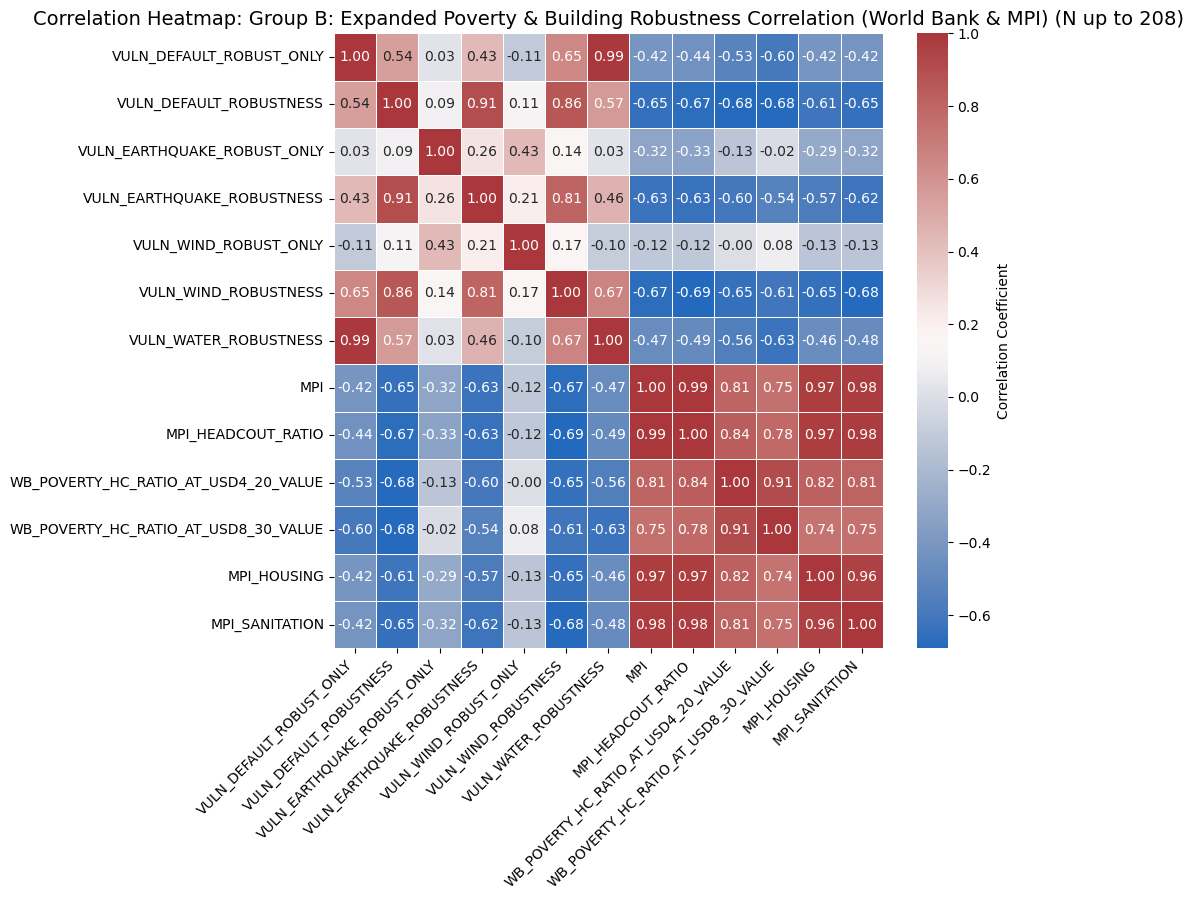


--- Correlation Matrix: Group B: Expanded Poverty & Building Robustness Correlation (World Bank & MPI) ---
                                      VULN_DEFAULT_ROBUST_ONLY  \
VULN_DEFAULT_ROBUST_ONLY                                  1.00   
VULN_DEFAULT_ROBUSTNESS                                   0.54   
VULN_EARTHQUAKE_ROBUST_ONLY                               0.03   
VULN_EARTHQUAKE_ROBUSTNESS                                0.43   
VULN_WIND_ROBUST_ONLY                                    -0.11   
VULN_WIND_ROBUSTNESS                                      0.65   
VULN_WATER_ROBUSTNESS                                     0.99   
MPI                                                      -0.42   
MPI_HEADCOUT_RATIO                                       -0.44   
WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE                     -0.53   
WB_POVERTY_HC_RATIO_AT_USD8_30_VALUE                     -0.60   
MPI_HOUSING                                              -0.42   
MPI_SANITATION                    

In [53]:
# === GROUP B: Poverty (MPI) and Building Robustness (Expanded) ===
group_b_vars = {
    'Robustness (Y)': expanded_robustness_vars, # <--- 変更
    'Poverty Indicators (X)': [
        'MPI',
        'MPI_HEADCOUT_RATIO',
        'WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE',
        'WB_POVERTY_HC_RATIO_AT_USD3_20_VALUE',
        'WB_POVERTY_HC_RATIO_AT_USD8_30_VALUE',
        'WB_POVERTY_HC_RATIO_NATIONAL_VALUE',
        'WB_POVERTY_GAP_VALUE',
        'WB_INCOME_MEAN_PPP_VALUE',
        'MPI_HOUSING',
        'MPI_SANITATION'
    ]
}
run_correlation_analysis(df_analysis, "Group B: Expanded Poverty & Building Robustness Correlation (World Bank & MPI)", group_b_vars)


## Disaster vs Robustness

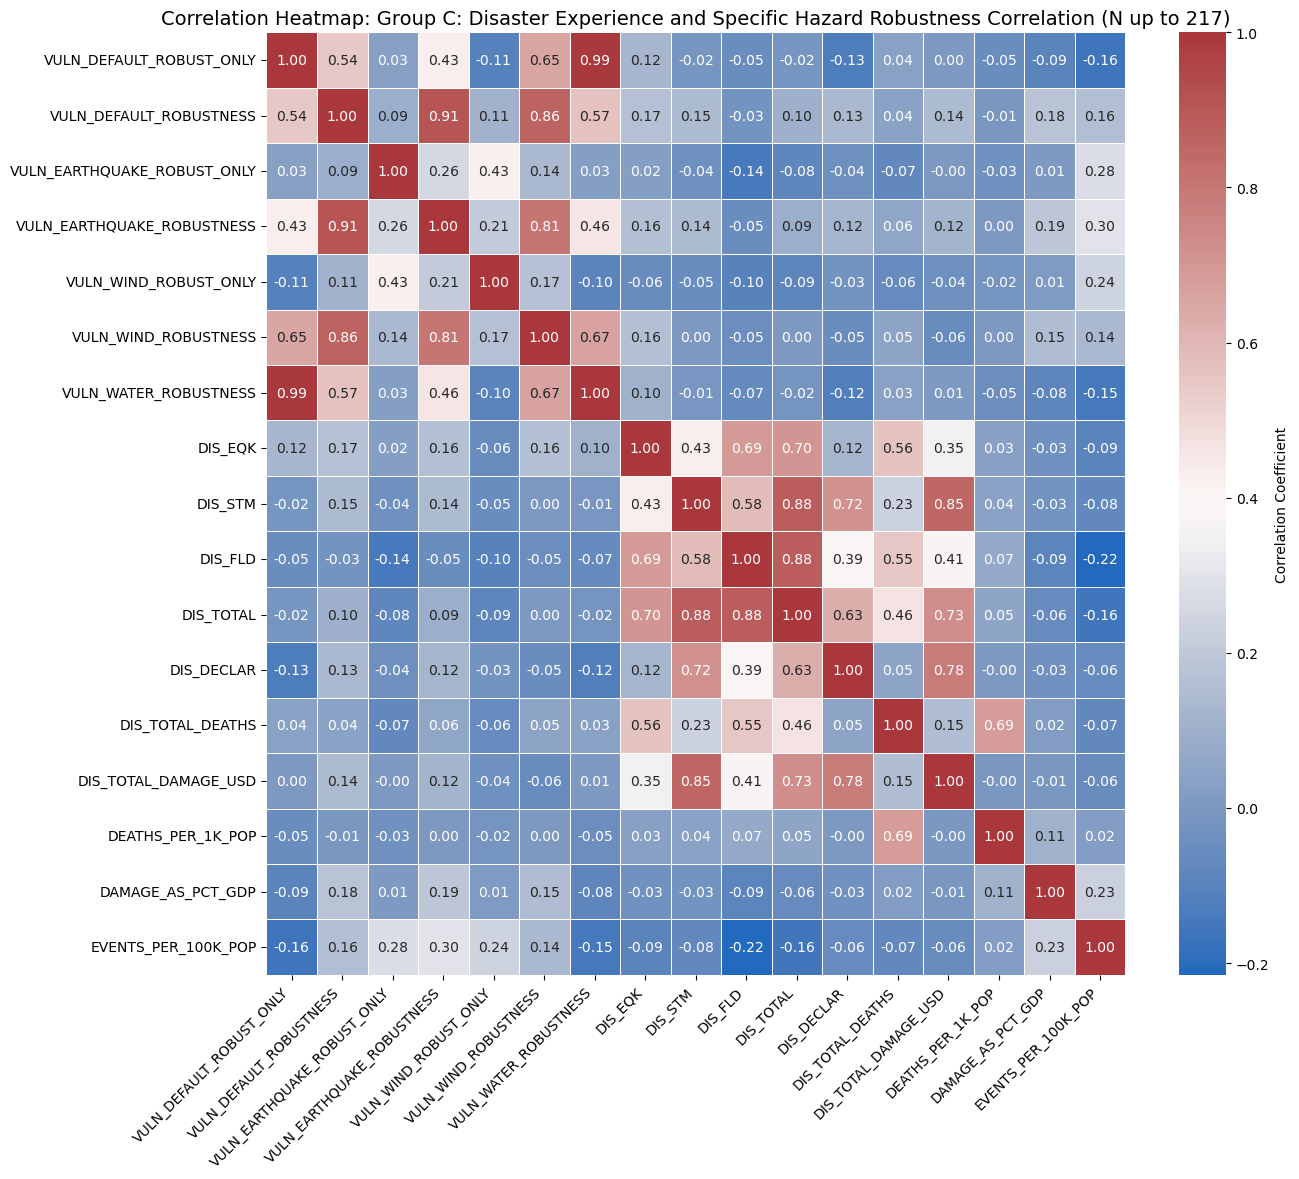


--- Correlation Matrix: Group C: Disaster Experience and Specific Hazard Robustness Correlation ---
                             VULN_DEFAULT_ROBUST_ONLY  \
VULN_DEFAULT_ROBUST_ONLY                         1.00   
VULN_DEFAULT_ROBUSTNESS                          0.54   
VULN_EARTHQUAKE_ROBUST_ONLY                      0.03   
VULN_EARTHQUAKE_ROBUSTNESS                       0.43   
VULN_WIND_ROBUST_ONLY                           -0.11   
VULN_WIND_ROBUSTNESS                             0.65   
VULN_WATER_ROBUSTNESS                            0.99   
DIS_EQK                                          0.12   
DIS_STM                                         -0.02   
DIS_FLD                                         -0.05   
DIS_TOTAL                                       -0.02   
DIS_DECLAR                                      -0.13   
DIS_TOTAL_DEATHS                                 0.04   
DIS_TOTAL_DAMAGE_USD                             0.00   
DEATHS_PER_1K_POP                           

In [54]:
# --- Group C: Correlation between Disaster Experience and Specific Hazard Robustness ---
group_c_vars = {
    'Specific Hazard Robustness (Y)': expanded_robustness_vars, # <--- 変更
    'Disaster Experience (X)': [
        'DIS_EQK',           # Earthquake (件数)
        'DIS_STM',           # Storm (件数)
        'DIS_FLD',           # Flood (件数)
        'DIS_TOTAL',         # Total Disasters (件数)
        'DIS_DECLAR',        # Total Declared Disasters (件数)
        'DIS_TOTAL_DEATHS',  # 死亡者総数 (実数)
        'DIS_TOTAL_DAMAGE_USD', # 被害総額 (実数)
        'DEATHS_PER_1K_POP',   # <-- 正規化指標: 人口千人当たり死亡者数
        'DAMAGE_AS_PCT_GDP',   # <-- 正規化指標: GDP比被害額 (%)
        'EVENTS_PER_100K_POP' # <-- 正規化指標: 人口十万人当たり災害イベント数
    ]
}
run_correlation_analysis(df_analysis, "Group C: Disaster Experience and Specific Hazard Robustness Correlation", group_c_vars)

# CSV export

In [55]:
# ----------------------------------------------------
# 📌 3. 新しいCSVとしてエクスポート
# ----------------------------------------------------
export_final_analysis_path = os.path.join(folder_path, "global_analysis_final_for_regression.csv")
df_analysis.to_csv(export_final_analysis_path, index=False, encoding='utf-8-sig')

print("\n--- 💾 CSVファイルのエクスポート完了 ---")
print(f"🎉 分析・Regression用の最終CSVファイルがエクスポートされました。")
print(f"パス: {export_final_analysis_path}")
print(f"最終的なデータ形状: {df_analysis.shape}")


--- 💾 CSVファイルのエクスポート完了 ---
🎉 分析・Regression用の最終CSVファイルがエクスポートされました。
パス: C:\Users\wb512463\OneDrive - WBG\Resilient Housing\Global analysis\data_processed\global_analysis_final_for_regression.csv
最終的なデータ形状: (217, 93)
